In [1]:
import os
from scipy.io import loadmat

# 데이터 경로 설정 (파일이 있는 폴더)
data_dir = "C:/Users/enjoy/Downloads/archive (2)/raw"  # ← 여기에 본인 경로 정확히 넣기

# 모든 .mat 파일 리스트 가져오기
mat_files = [f for f in os.listdir(data_dir) if f.endswith(".mat")]

print("찾은 파일 목록:")
print(mat_files)

찾은 파일 목록:
['B007_1_123.mat', 'B014_1_190.mat', 'B021_1_227.mat', 'IR007_1_110.mat', 'IR014_1_175.mat', 'IR021_1_214.mat', 'OR007_6_1_136.mat', 'OR014_6_1_202.mat', 'OR021_6_1_239.mat', 'Time_Normal_1_098.mat']


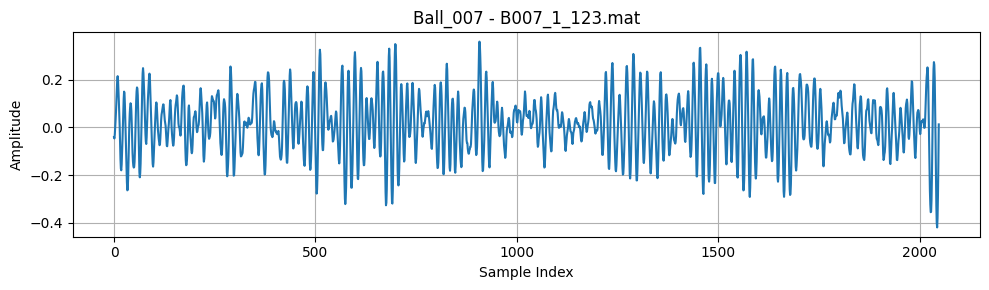

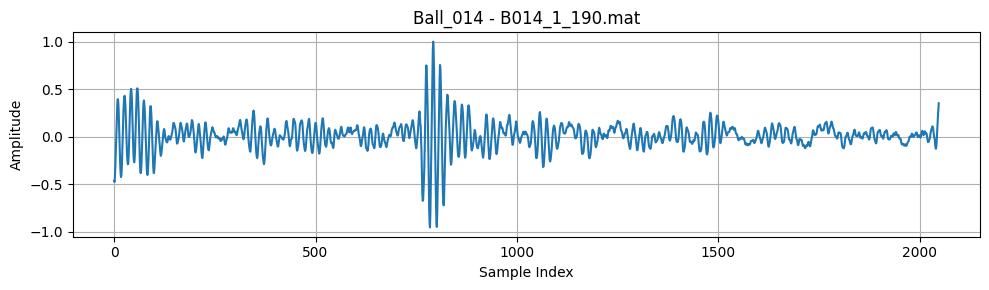

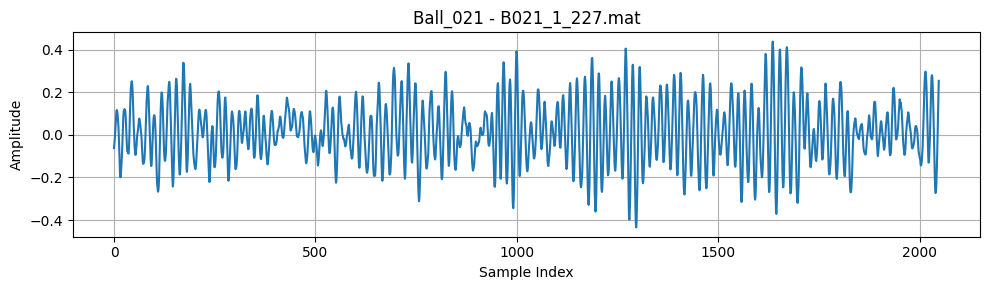

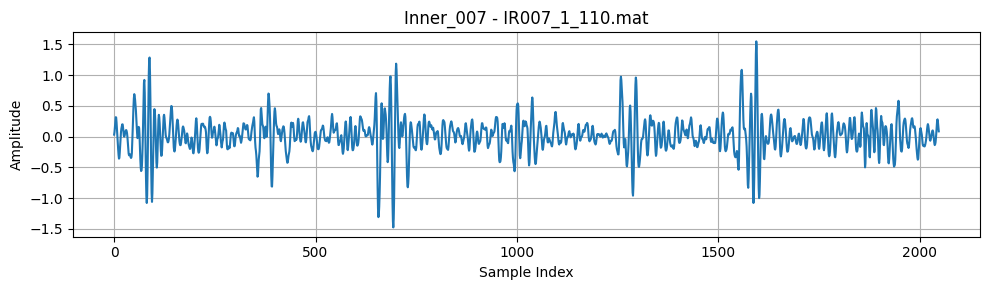

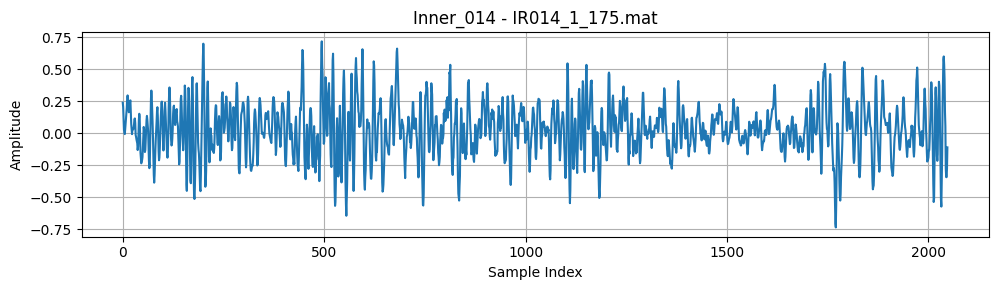

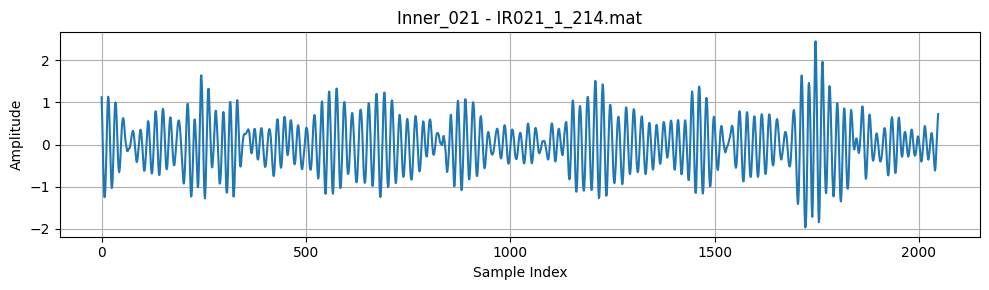

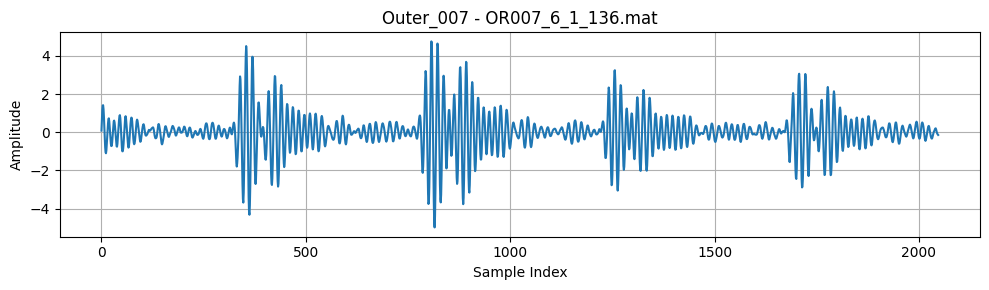

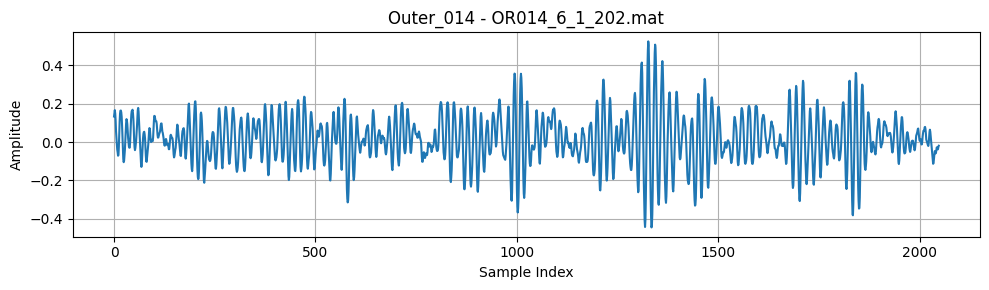

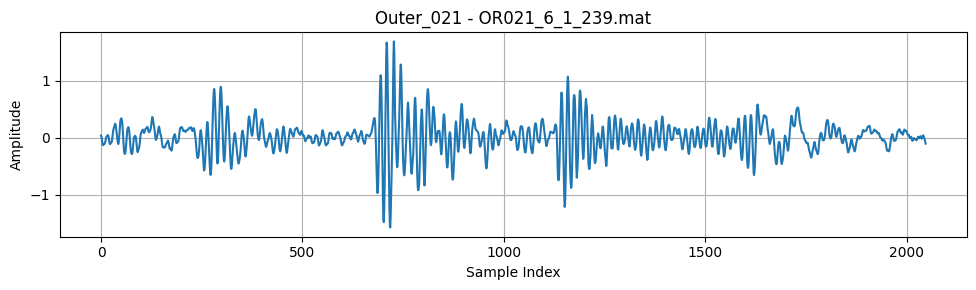

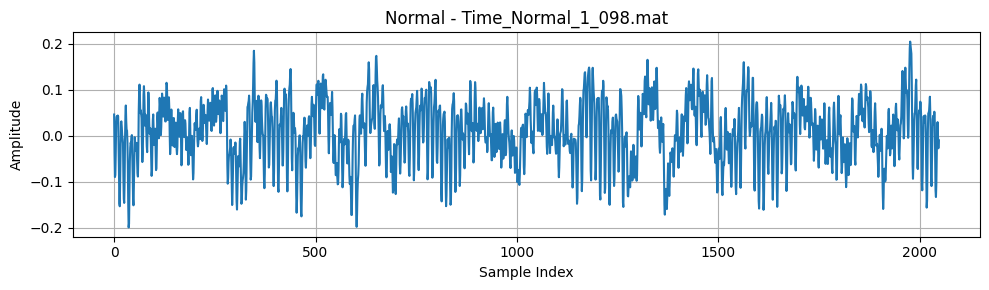

In [ ]:
# 진동 파형 시각화 
import os
import matplotlib.pyplot as plt
from scipy.io import loadmat

# 1. 경로 설정
data_dir = "C:/Users/enjoy/Downloads/archive (2)/raw"  # 본인 경로로 수정

# 2. 유형별 파일 이름 정의
mat_files = {
    'Ball_007': 'B007_1_123.mat',
    'Ball_014': 'B014_1_190.mat',
    'Ball_021': 'B021_1_227.mat',
    'Inner_007': 'IR007_1_110.mat',
    'Inner_014': 'IR014_1_175.mat',
    'Inner_021': 'IR021_1_214.mat',
    'Outer_007': 'OR007_6_1_136.mat',
    'Outer_014': 'OR014_6_1_202.mat',
    'Outer_021': 'OR021_6_1_239.mat',
    'Normal': 'Time_Normal_1_098.mat'
}

# 3. 시각화
for fault_type, file_name in mat_files.items():
    file_path = os.path.join(data_dir, file_name)
    mat = loadmat(file_path)

    # 드라이브 엔드 채널(DE) 키 추출
    signal_key = [k for k in mat.keys() if "DE" in k][0]
    signal = mat[signal_key].squeeze()

    # 시각화
    plt.figure(figsize=(10, 3))
    plt.plot(signal[:2048])
    plt.title(f"{fault_type} - {file_name}")
    plt.xlabel("Sample Index")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

| 구분     | 진폭 크기        | 신호 패턴       | 결함 해석       |
| ------ | ------------ | ----------- | ----------- |
| Normal | 매우 작음 (±0.1) | 안정적, 주기적    | 이상 없음       |
| Ball   | 중간           | 날카로운 고주파 반복 | 접촉 충격 반복    |
| Inner  | 가장 큼         | 불규칙, 급격한 피크 | 근거리 충격      |
| Outer  | 큼            | 주기적 펄스      | 회전 주기 기반 충격 |


불량 유형별로 진동 파형에서 뚜렷한 패턴 차이가 관측되며, 특히 내륜 결함은 진폭이 가장 크고 불규칙하며, 
볼 결함은 고주파 반복성이, 외륜 결함은 주기적 진폭 변화가 뚜렷하게 나타난다.

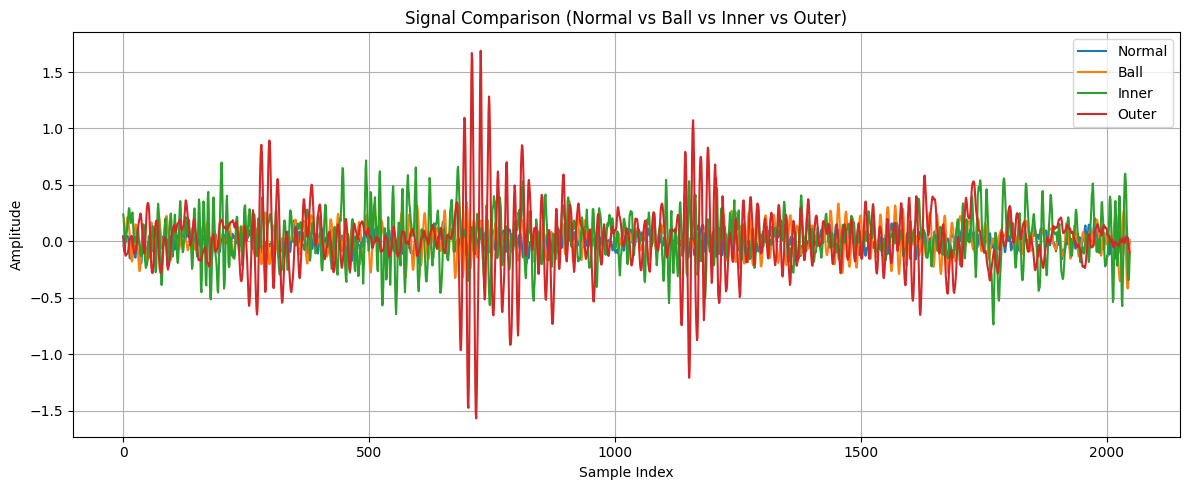

In [ ]:
# 불량 유형별 진동 신호의 차이
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# 경로 설정
data_dir = "C:/Users/enjoy/Downloads/archive (2)/raw" 

# 대표 샘플
file_map = {
    'Normal': 'Time_Normal_1_098.mat',
    'Ball': 'B007_1_123.mat',
    'Inner': 'IR014_1_175.mat',
    'Outer': 'OR021_6_1_239.mat'
}

# 시각화 준비
plt.figure(figsize=(12, 5))

for label, fname in file_map.items():
    path = os.path.join(data_dir, fname)
    mat = loadmat(path)
    signal_key = [k for k in mat.keys() if "DE" in k][0]
    signal = mat[signal_key].squeeze()
    
    plt.plot(signal[:2048], label=label)

plt.title("Signal Comparison (Normal vs Ball vs Inner vs Outer)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Normal은 진폭이 매우 작고 규칙적이며, Inner fault는 큰 진폭 변화가 불규칙하게 나타나는 반면, 
# Ball fault는 고주파 성분이 반복적으로 나타나며, Outer fault는 일정 주기로 강한 충격이 발생
# 이러한 차이가 RMS나 kurtosis 같은 통계치로도 반영되어, 모델이 이를 학습해 불량 유형을 분류할 수 있다.


| 라벨               | 파형 특징                         | 해석                            |
| ---------------- | ----------------------------- | ----------------------------- |
| **Normal (파란색)** | 진폭 작고 매끄럽고 규칙적                | 정상 상태의 안정적인 진동 신호             |
| **Ball (주황색)**   | 중간 진폭, 고주파성 짧은 스파이크           | 볼 표면 충격으로 인한 반복적인 고주파 진동      |
| **Inner (초록색)**  | 불규칙적이고 비교적 큰 진폭               | 내륜 손상으로 인한 비정상 충격, 진폭 변화 큼    |
| **Outer (빨간색)**  | 특정 구간에서 **급격히 큰 진폭**, 주기적인 패턴 | 외륜에 위치한 결함으로 **간헐적 강한 충격 발생** |


## FFT

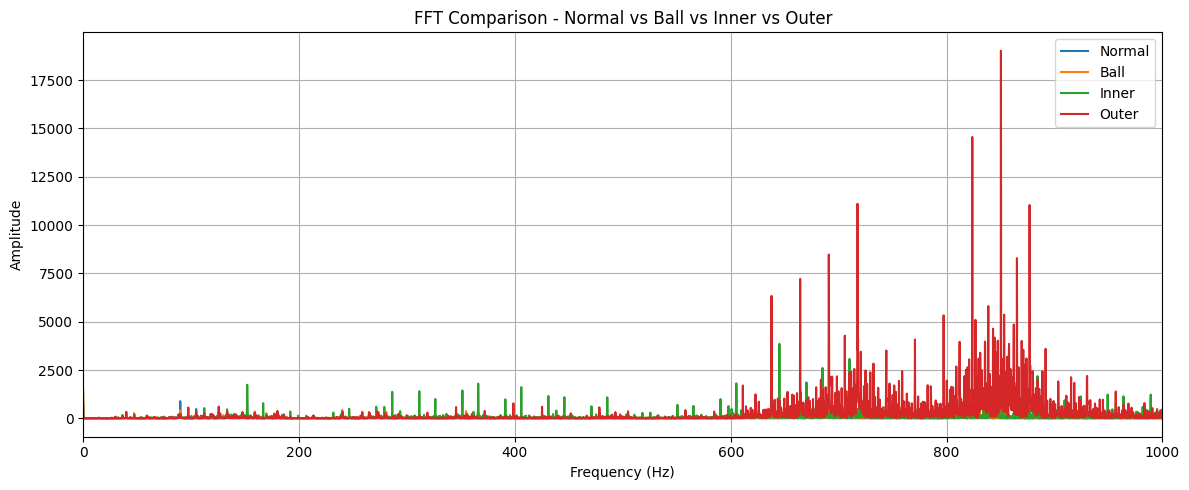

In [ ]:
# x:주파수 y:진폭(Amplitude)
# FFT는 진동 신호를 분석해, 고장이 발생했을 때 어떤 주파수에서 얼마나 강한 진동이 나오는지를 보여줌
# 이를 통해 고장 유형마다 고유한 주파수 패턴이 있음을 시각적으로 확인

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.fft import fft

# 1. 경로 설정
data_dir = "C:/Users/enjoy/Downloads/archive (2)/raw" 

# 2. 유형별 파일 리스트
file_map = {
    "Normal": ["Time_Normal_1_098.mat"],
    "Ball": ["B007_1_123.mat", "B014_1_190.mat", "B021_1_227.mat"],
    "Inner": ["IR007_1_110.mat", "IR014_1_175.mat", "IR021_1_214.mat"],
    "Outer": ["OR007_6_1_136.mat", "OR014_6_1_202.mat", "OR021_6_1_239.mat"]
}

# ---------------------------------------------------
# 3. 신호 로딩 함수
def load_signals(file_list, base_path):
    all_signals = []
    for fname in file_list:
        mat = loadmat(os.path.join(base_path, fname))
        key = [k for k in mat if 'DE' in k][0]  # DE_signal 키 탐색
        signal = mat[key].squeeze()
        all_signals.append(signal)
    return np.concatenate(all_signals)

# ---------------------------------------------------
# 4. FFT 시각화 함수
def plot_fft(signal, fs=12000, label=''):
    N = len(signal)
    freqs = np.linspace(0, fs/2, N//2)
    fft_values = np.abs(fft(signal))[:N//2]

    plt.plot(freqs, fft_values, label=label)

# ---------------------------------------------------
# 5. 모든 결함 유형별 FFT 시각화
plt.figure(figsize=(12, 5))

for label, file_list in file_map.items():
    signal = load_signals(file_list, data_dir)
    signal = signal[:65536]  # 길이 제한 (2^n), 너무 길면 자름
    plot_fft(signal, label=label)

plt.title("FFT Comparison - Normal vs Ball vs Inner vs Outer")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
plt.xlim(0, 1000)  # 주로 0~1000Hz 구간이 주요 주파수 영역
plt.tight_layout()
plt.show()

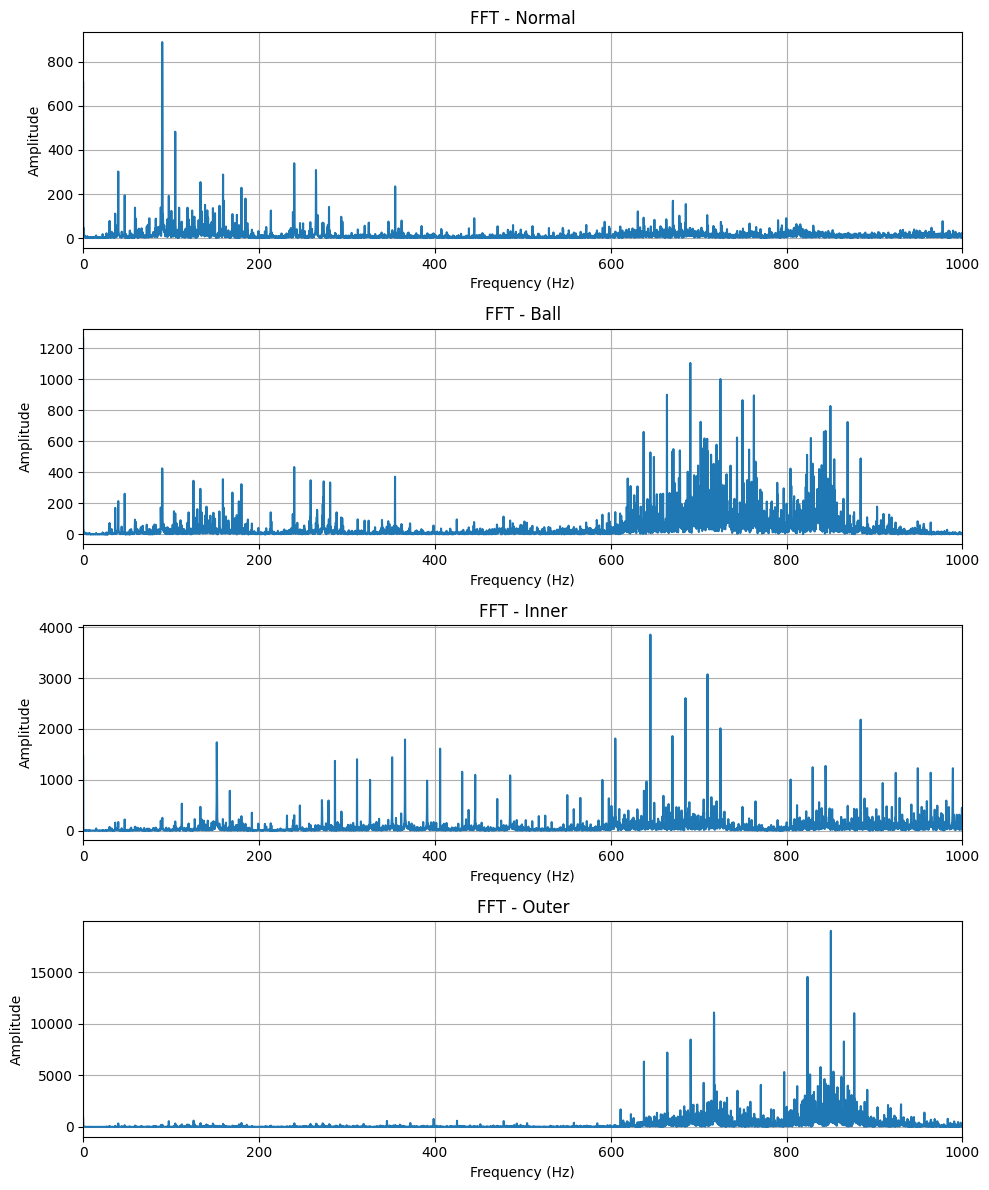

In [ ]:
#  유형별 파일 리스트
file_map = {
    "Normal": ["Time_Normal_1_098.mat"],
    "Ball": ["B007_1_123.mat", "B014_1_190.mat", "B021_1_227.mat"],
    "Inner": ["IR007_1_110.mat", "IR014_1_175.mat", "IR021_1_214.mat"],
    "Outer": ["OR007_6_1_136.mat", "OR014_6_1_202.mat", "OR021_6_1_239.mat"]
}


#  신호 로딩 함수
def load_signals(file_list, base_path):
    all_signals = []
    for fname in file_list:
        mat = loadmat(os.path.join(base_path, fname))
        key = [k for k in mat if 'DE' in k][0]
        signal = mat[key].squeeze()
        all_signals.append(signal)
    return np.concatenate(all_signals)

#  FFT 시각화 함수 (subplot)
def plot_fft_subplot(signal, fs, label, subplot_idx):
    N = len(signal)
    freqs = np.linspace(0, fs/2, N//2)
    fft_values = np.abs(fft(signal))[:N//2]

    plt.subplot(4, 1, subplot_idx)
    plt.plot(freqs, fft_values)
    plt.title(f"FFT - {label}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.xlim(0, 1000)

#  실행
plt.figure(figsize=(10, 12))
fs = 12000  # 샘플링 주파수

for idx, (label, files) in enumerate(file_map.items(), start=1):
    signal = load_signals(files, data_dir)
    plot_fft_subplot(signal[:65536], fs, label, idx)

plt.tight_layout()
plt.show()

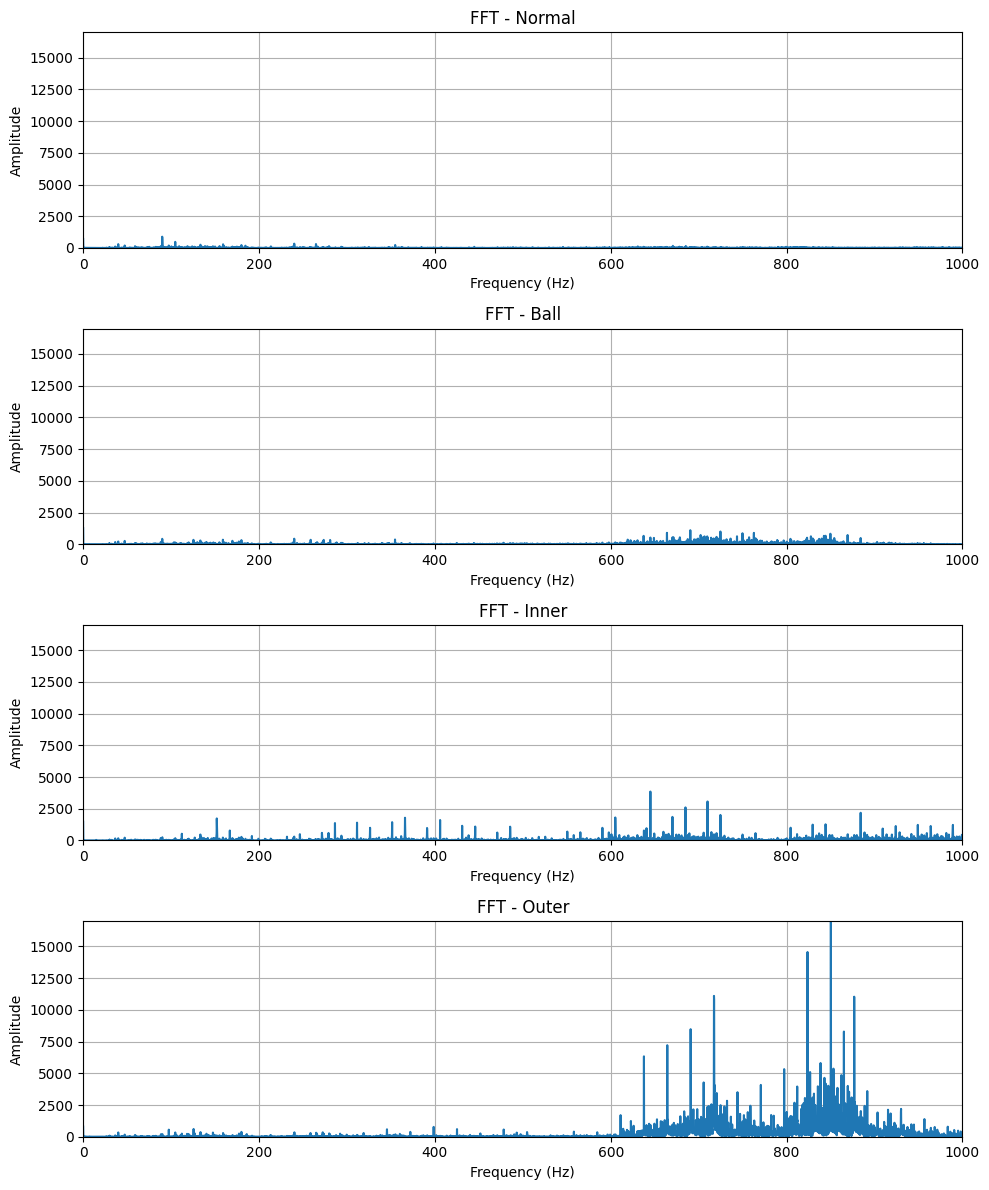

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.fft import fft

# 1. 데이터 경로 설정 (본인 경로에 맞게 수정)
data_dir = "C:/Users/enjoy/Downloads/archive (2)/raw"  # ← 경로 수정 필요

# 2. 유형별 .mat 파일 목록
file_map = {
    "Normal": ["Time_Normal_1_098.mat"],
    "Ball": ["B007_1_123.mat", "B014_1_190.mat", "B021_1_227.mat"],
    "Inner": ["IR007_1_110.mat", "IR014_1_175.mat", "IR021_1_214.mat"],
    "Outer": ["OR007_6_1_136.mat", "OR014_6_1_202.mat", "OR021_6_1_239.mat"]
}

# 3. 신호 로딩 함수 (유형별 여러 파일 연결)
def load_signals(file_list, base_path):
    all_signals = []
    for fname in file_list:
        mat = loadmat(os.path.join(base_path, fname))
        key = [k for k in mat if 'DE' in k][0]
        signal = mat[key].squeeze()
        all_signals.append(signal)
    return np.concatenate(all_signals)

# 4. FFT 시각화 함수 (서브플롯 + Y축 통일)
def plot_fft_subplot(signal, fs, label, subplot_idx, y_max):
    N = len(signal)
    freqs = np.linspace(0, fs/2, N//2)
    fft_values = np.abs(fft(signal))[:N//2]

    plt.subplot(4, 1, subplot_idx)
    plt.plot(freqs, fft_values)
    plt.title(f"FFT - {label}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Amplitude")
    plt.grid(True)
    plt.xlim(0, 1000)
    plt.ylim(0, y_max)  # Y축 고정

# 5. 실행
fs = 12000  # 샘플링 주파수
y_max = 17000  # Y축 최대값 통일 (Outer 기준)

plt.figure(figsize=(10, 12))

for idx, (label, files) in enumerate(file_map.items(), start=1):
    signal = load_signals(files, data_dir)
    signal = signal[:65536]  # 너무 길면 잘라서 FFT 적용
    plot_fft_subplot(signal, fs, label, idx, y_max)

plt.tight_layout()
plt.show()
